In [2]:
!pip install plotly


   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.9 MB 3.0 MB/s eta 0:00:03
   ----- ---------------------------------- 1.3/9.9 MB 2.8 MB/s eta 0:00:04
   ------- -------------------------------- 1.8/9.9 MB 2.5 MB/s eta 0:00:04
   --------- ------------------------------ 2.4/9.9 MB 2.5 MB/s eta 0:00:04
   ----------- ---------------------------- 2.9/9.9 MB 2.6 MB/s eta 0:00:03
   ------------- -------------------------- 3.4/9.9 MB 2.6 MB/s eta 0:00:03
   --------------- ------------------------ 3.9/9.9 MB 2.6 MB/s eta 0:00:03
   ----------------- ---------------------- 4.5/9.9 MB 2.6 MB/s eta 0:00:03
   -------------------- ------------------- 5.0/9.9 MB 2.6 MB/s eta 0:00:02
   ---------------------- ----------------- 5.5/9.9 MB 2.5 MB/s eta 0:00:02
   ----------------------- ---------------- 5.8/9.9 MB 2.5 MB/s eta 0:00:02
   -----------------------

In [5]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

In [6]:
# Step 2: Load and preview data
df = pd.read_csv("traffic.csv")   # replace with your file path
df.head()

,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


In [11]:
print(df.columns)


Index(['event', 'date', 'country', 'city', 'artist', 'album', 'track', 'isrc',
       'linkid'],
      dtype='str')


In [14]:
!pip install squarify


Total Events: 226241
Unique Tracks: 3547
Unique Artists: 2419
Unique Albums: 3241
Countries: 211
Cities: 11992


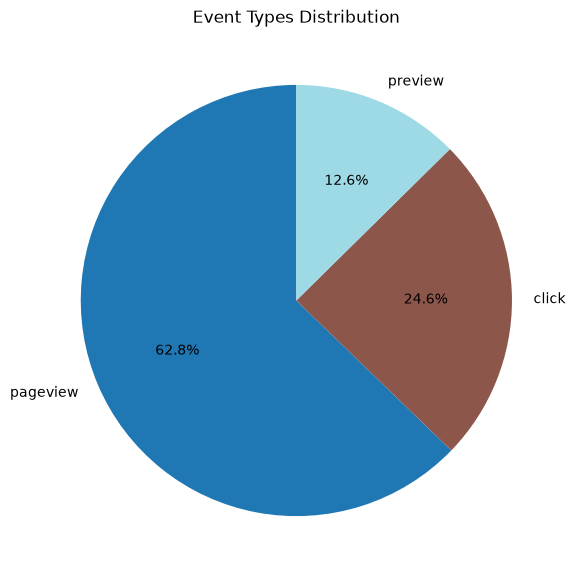

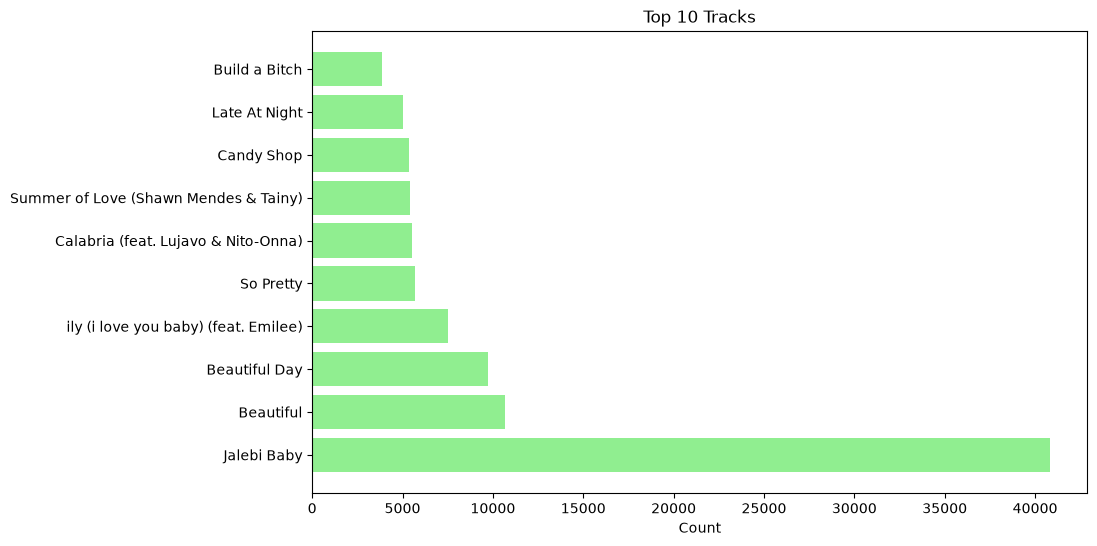

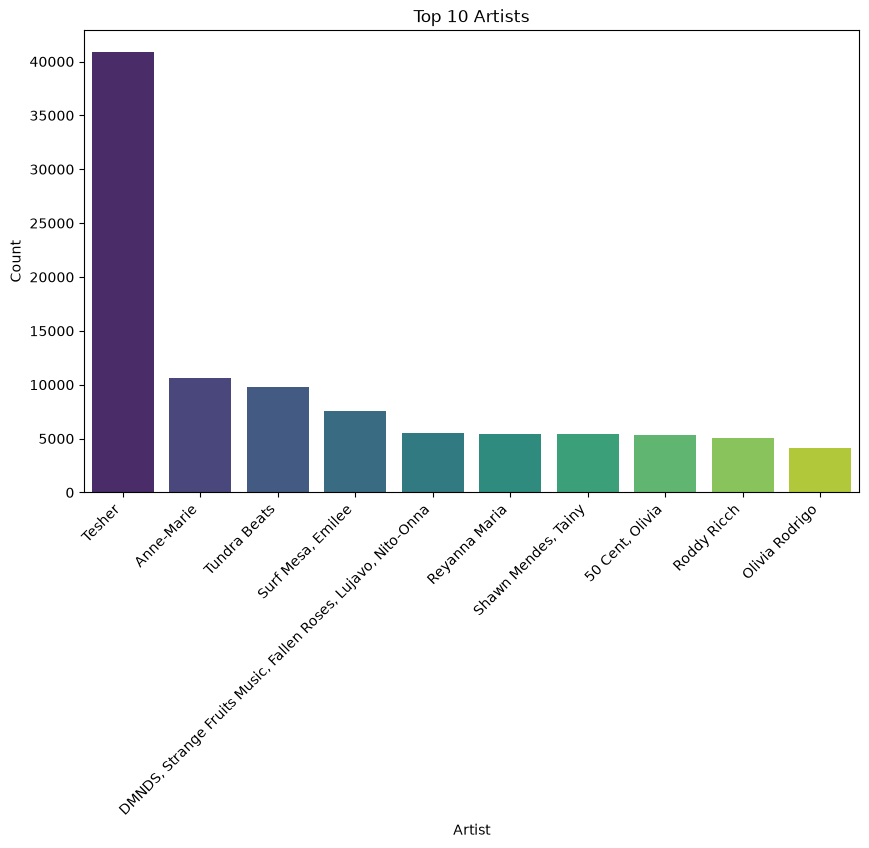

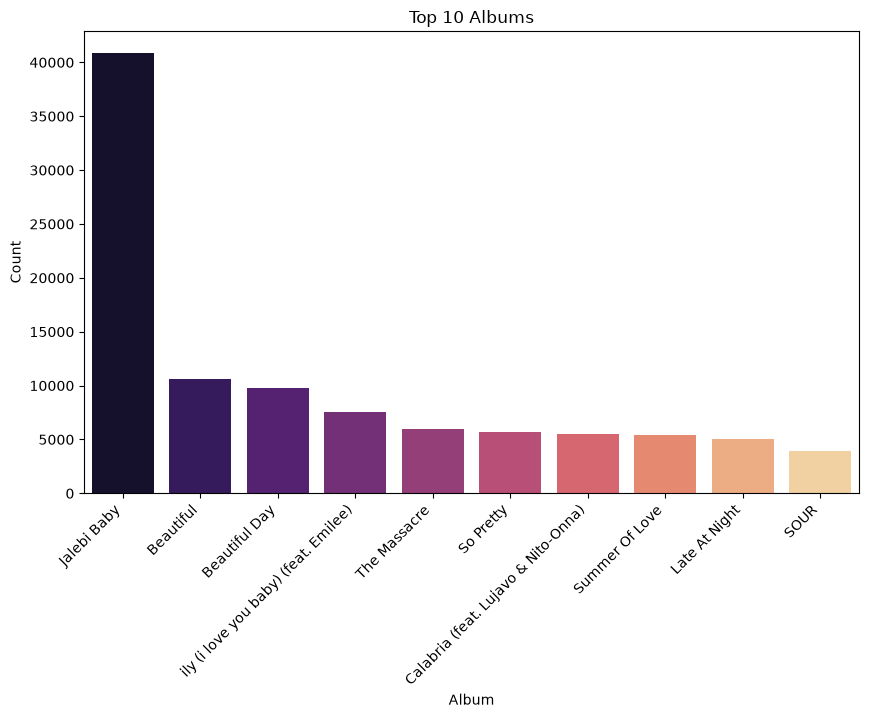

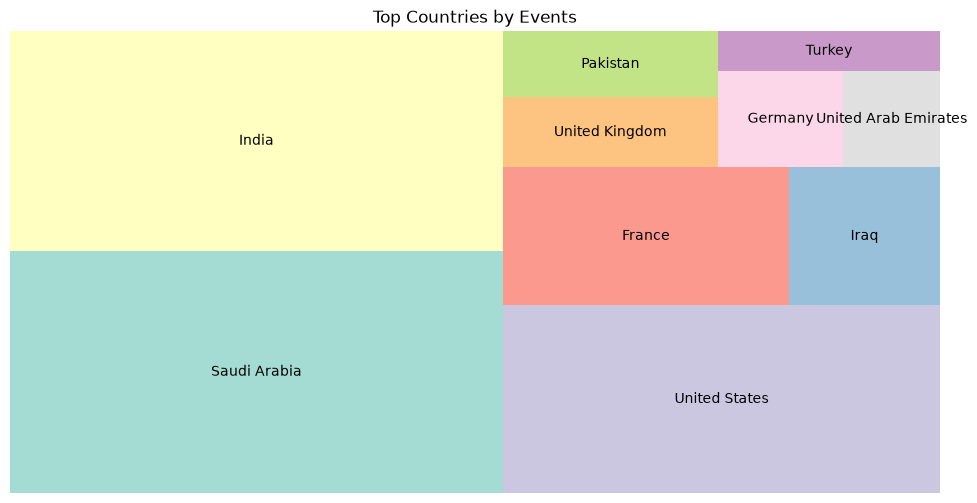

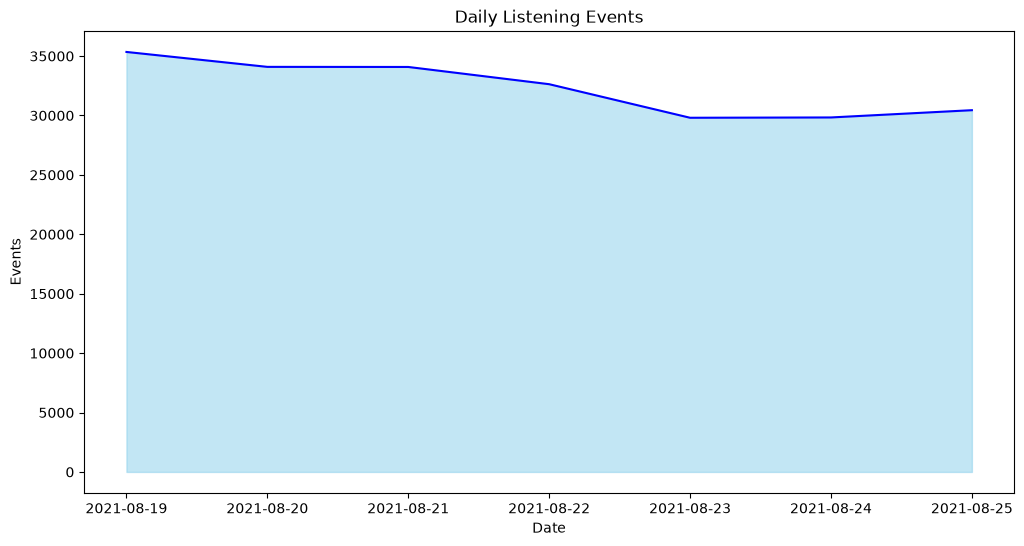

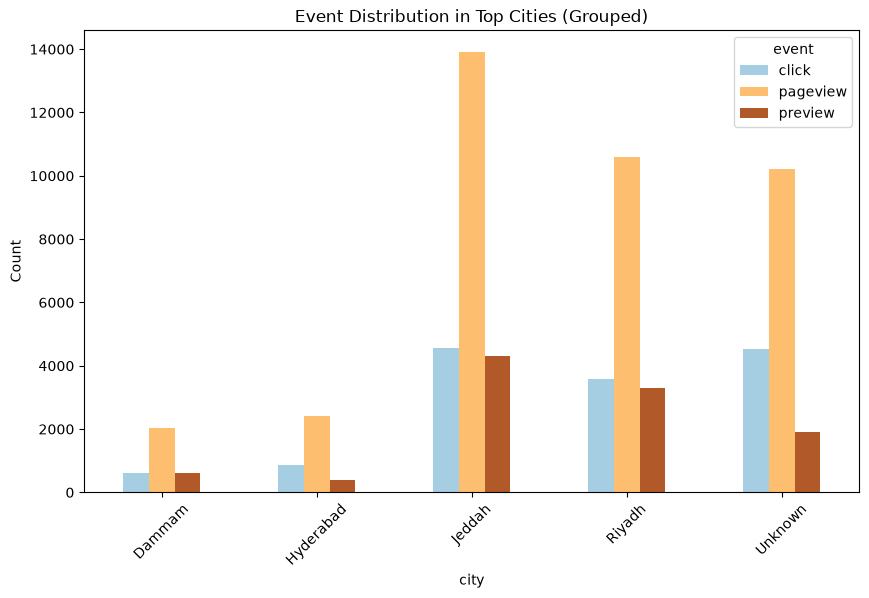

In [19]:
# Step 3: Basic metrics
print("Total Events:", len(df))
print("Unique Tracks:", df['track'].nunique())
print("Unique Artists:", df['artist'].nunique())
print("Unique Albums:", df['album'].nunique())
print("Countries:", df['country'].nunique())
print("Cities:", df['city'].nunique())

# Step 4: Event type distribution (Pie chart)
plt.figure(figsize=(7,7))
df['event'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90, cmap='tab20')
plt.title("Event Types Distribution")
plt.ylabel("")
plt.show()

# Step 5: Top tracks (Horizontal bar chart)
top_tracks = df['track'].value_counts().head(10)
plt.figure(figsize=(10,6))
plt.barh(top_tracks.index, top_tracks.values, color='lightgreen')
plt.title("Top 10 Tracks")
plt.xlabel("Count")
plt.show()

# step 6: Top 10 Artists
top_artists = df['artist'].value_counts().head(10).sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=top_artists.index, y=top_artists.values, hue=top_artists.index,
            palette="viridis", legend=False)
plt.title("Top 10 Artists")
plt.xlabel("Artist")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.show()

# Step 7: Top 10 Albums
top_albums = df['album'].value_counts().head(10).sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=top_albums.index, y=top_albums.values, hue=top_albums.index,
            palette="magma", legend=False)
plt.title("Top 10 Albums")
plt.xlabel("Album")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.show()

# Step 8: Country distribution (Treemap)
import squarify
top_countries = df['country'].value_counts().head(10)
plt.figure(figsize=(12,6))
squarify.plot(sizes=top_countries.values, label=top_countries.index, alpha=0.8, color=sns.color_palette("Set3"))
plt.title("Top Countries by Events")
plt.axis("off")
plt.show()

# Step 9: Daily listening trends (Area chart)
daily_counts = df.groupby(df['date'].dt.date)['track'].count()
plt.figure(figsize=(12,6))
plt.fill_between(daily_counts.index, daily_counts.values, color="skyblue", alpha=0.5)
plt.plot(daily_counts.index, daily_counts.values, color="blue")
plt.title("Daily Listening Events")
plt.xlabel("Date")
plt.ylabel("Events")
plt.show()

# Top 5 cities
top_cities = df['city'].value_counts().head(5)

# Event counts by city
city_event = df[df['city'].isin(top_cities.index)].groupby(['city','event']).size().unstack(fill_value=0)

# Grouped bar chart
city_event.plot(kind='bar', figsize=(10,6), colormap="Paired")
plt.title("Event Distribution in Top Cities (Grouped)")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()
